# Stage 08: Exploratory Data Analysis — AAPL Daily Market Data

This notebook profiles the 100-day AAPL OHLCV dataset acquired in Stage 04 and translates the findings into preprocessing and feature-engineering choices for later stages.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.eda import eda_summary

SOURCE_PATH = PROJECT_ROOT.parent / "stage4/data/raw/api_alpha_vantage_AAPL_20260821-1152.csv"
RAW_PATH = PROJECT_ROOT / "data/raw/aapl_daily_ohlcv.csv"
RAW_PATH.parent.mkdir(parents=True, exist_ok=True)
source_df = pd.read_csv(SOURCE_PATH)
source_df.to_csv(RAW_PATH, index=False)
print("Copied project dataset to:", RAW_PATH.relative_to(PROJECT_ROOT))
sns.set_theme(style="whitegrid", context="notebook")

Matplotlib is building the font cache; this may take a moment.


Copied project dataset to: data/raw/aapl_daily_ohlcv.csv


## 1. Load Data and Engineer EDA Fields

The original OHLCV columns remain unchanged. Derived fields support interpretation: close-to-close return, absolute return, intraday range as a share of open, price direction, weekday, and volume tercile.

In [2]:
df = pd.read_csv(RAW_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
df["daily_return"] = df["close"].pct_change()
df["absolute_return"] = df["daily_return"].abs()
df["intraday_range_pct"] = (df["high"] - df["low"]) / df["open"]
df["direction"] = np.select(
    [df["close"] > df["open"], df["close"] < df["open"]],
    ["Up", "Down"], default="Flat")
df["direction"] = df["direction"].astype("string")
df["weekday"] = df["date"].dt.day_name().astype("string")
df["volume_band"] = pd.qcut(df["volume"], q=3, labels=["Low", "Medium", "High"])
print("Shape:", df.shape)
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
display(df.head())

Shape: (100, 12)
Date range: 2026-03-30 to 2026-08-20


,date,open,high,low,close,volume,daily_return,absolute_return,intraday_range_pct,direction,weekday,volume_band
0,2026-03-30,250.07,250.87,245.510,246.63,39446213,NaN,NaN,0.021434,Down,Monday,Low
1,2026-03-31,247.91,255.48,247.101,253.79,49598091,0.029031,0.029031,0.033799,Up,Tuesday,Medium
2,2026-04-01,254.08,256.18,253.330,255.63,40059432,0.007250,0.007250,0.011217,Up,Wednesday,Low
3,2026-04-02,254.20,256.13,250.650,255.92,31289369,0.001134,0.001134,0.021558,Up,Thursday,Low
4,2026-04-06,256.51,262.16,256.460,258.86,29329911,0.011488,0.011488,0.022221,Up,Monday,Low


## 2. Comprehensive Profiling

In [3]:
print("DataFrame.info():")
df.info()
print("\nMissing counts:")
display(df.isna().sum().rename("missing_count").to_frame())
print("Numeric describe():")
display(df.describe(include=[np.number]).T)
numeric_shape = df.select_dtypes(include="number").agg(["skew", "kurt"]).T
display(numeric_shape.rename(columns={"kurt": "kurtosis"}))

DataFrame.info():
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                100 non-null    datetime64[us]
 1   open                100 non-null    float64       
 2   high                100 non-null    float64       
 3   low                 100 non-null    float64       
 4   close               100 non-null    float64       
 5   volume              100 non-null    int64         
 6   daily_return        99 non-null     float64       
 7   absolute_return     99 non-null     float64       
 8   intraday_range_pct  100 non-null    float64       
 9   direction           100 non-null    string        
 10  weekday             100 non-null    string        
 11  volume_band         100 non-null    category      
dtypes: category(1), datetime64[us](1), float64(7), int64(1), string(2)
memory usage: 9.9 KB

Missing cou

,missing_count
date,0
open,0
high,0
low,0
close,0
volume,0
daily_return,1
absolute_return,1
intraday_range_pct,0
direction,0


Numeric describe():


,count,mean,std,min,25%,50%,75%,max
open,100.0,2.956684e+02,2.245542e+01,2.479100e+02,2.783725e+02,2.990000e+02,3.105525e+02,3.400300e+02
high,100.0,2.994369e+02,2.278706e+01,2.508700e+02,2.856050e+02,3.022450e+02,3.148650e+02,3.445699e+02
low,100.0,2.927689e+02,2.234422e+01,2.455100e+02,2.746976e+02,2.959850e+02,3.081950e+02,3.373501e+02
close,100.0,2.964490e+02,2.256844e+01,2.466300e+02,2.793125e+02,2.991050e+02,3.112475e+02,3.400800e+02
volume,100.0,5.225962e+07,2.672834e+07,2.812157e+07,4.071791e+07,4.640415e+07,5.349850e+07,2.617754e+08
daily_return,99.0,2.524029e-03,1.840416e-02,-7.353867e-02,-7.840860e-03,3.521235e-03,1.169945e-02,4.840682e-02
absolute_return,99.0,1.363310e-02,1.254556e-02,3.838919e-05,5.288238e-03,1.086745e-02,1.797137e-02,7.353867e-02
intraday_range_pct,100.0,2.257403e-02,9.227757e-03,9.263057e-03,1.602234e-02,2.143664e-02,2.567616e-02,5.351557e-02


,skew,kurtosis
open,-0.324160,-0.630045
high,-0.343168,-0.597621
low,-0.325418,-0.608835
close,-0.292369,-0.644371
volume,5.356734,38.676332
daily_return,-0.834670,3.303072
absolute_return,2.111445,6.290824
intraday_range_pct,1.285862,2.012918


### Categorical Profile

Every categorical/text field is profiled below. `date` is intentionally treated as a temporal variable rather than a category.


Value counts — direction


,count
direction,
Up,60
Down,40



Value counts — weekday


,count
weekday,
Tuesday,21
Wednesday,21
Thursday,21
Monday,20
Friday,17



Value counts — volume_band


,count
volume_band,
Low,34
Medium,33
High,33


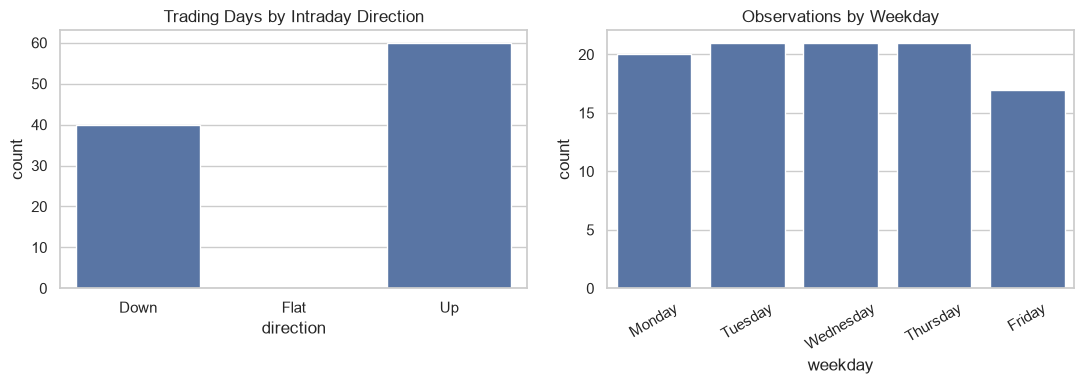

In [4]:
categorical_columns = list(df.select_dtypes(include=["object", "string", "category"]).columns)
for column in categorical_columns:
    print(f"\nValue counts — {column}")
    display(df[column].value_counts(dropna=False).rename("count").to_frame())

figure, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df, x="direction", order=["Down", "Flat", "Up"], ax=axes[0])
sns.countplot(data=df, x="weekday", order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"], ax=axes[1])
axes[0].set_title("Trading Days by Intraday Direction")
axes[1].set_title("Observations by Weekday")
axes[1].tick_params(axis="x", rotation=30)
figure.tight_layout()
plt.show()

## 3. Reusable `eda_summary()`

The imported helper packages the main profile and flags high missingness, constant/near-zero-variance fields, and dominating categories before Stage 09.

In [5]:
profile = eda_summary(df)
print(profile["info"])
display(profile["missing"])
display(profile["numeric_profile"])
print("Attention flags:")
display(profile["attention_flags"] if not profile["attention_flags"].empty else pd.DataFrame({"status": ["No columns crossed configured thresholds"]}))

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                100 non-null    datetime64[us]
 1   open                100 non-null    float64       
 2   high                100 non-null    float64       
 3   low                 100 non-null    float64       
 4   close               100 non-null    float64       
 5   volume              100 non-null    int64         
 6   daily_return        99 non-null     float64       
 7   absolute_return     99 non-null     float64       
 8   intraday_range_pct  100 non-null    float64       
 9   direction           100 non-null    string        
 10  weekday             100 non-null    string        
 11  volume_band         100 non-null    category      
dtypes: category(1), datetime64[us](1), float64(7), int64(1), string(2)
memory usage: 9.9 KB



,missing_count,missing_fraction
date,0,0.00
open,0,0.00
high,0,0.00
low,0,0.00
close,0,0.00
volume,0,0.00
daily_return,1,0.01
absolute_return,1,0.01
intraday_range_pct,0,0.00
direction,0,0.00


,count,mean,std,min,25%,50%,75%,max,missing_count,missing_fraction,skew,kurtosis
open,100.0,2.956684e+02,2.245542e+01,2.479100e+02,2.783725e+02,2.990000e+02,3.105525e+02,3.400300e+02,0,0.00,-0.324160,-0.630045
high,100.0,2.994369e+02,2.278706e+01,2.508700e+02,2.856050e+02,3.022450e+02,3.148650e+02,3.445699e+02,0,0.00,-0.343168,-0.597621
low,100.0,2.927689e+02,2.234422e+01,2.455100e+02,2.746976e+02,2.959850e+02,3.081950e+02,3.373501e+02,0,0.00,-0.325418,-0.608835
close,100.0,2.964490e+02,2.256844e+01,2.466300e+02,2.793125e+02,2.991050e+02,3.112475e+02,3.400800e+02,0,0.00,-0.292369,-0.644371
volume,100.0,5.225962e+07,2.672834e+07,2.812157e+07,4.071791e+07,4.640415e+07,5.349850e+07,2.617754e+08,0,0.00,5.356734,38.676332
daily_return,99.0,2.524029e-03,1.840416e-02,-7.353867e-02,-7.840860e-03,3.521235e-03,1.169945e-02,4.840682e-02,1,0.01,-0.834670,3.303072
absolute_return,99.0,1.363310e-02,1.254556e-02,3.838919e-05,5.288238e-03,1.086745e-02,1.797137e-02,7.353867e-02,1,0.01,2.111445,6.290824
intraday_range_pct,100.0,2.257403e-02,9.227757e-03,9.263057e-03,1.602234e-02,2.143664e-02,2.567616e-02,5.351557e-02,0,0.00,1.285862,2.012918


Attention flags:


,status
0,No columns crossed configured thresholds


## 4. Distributional Plots

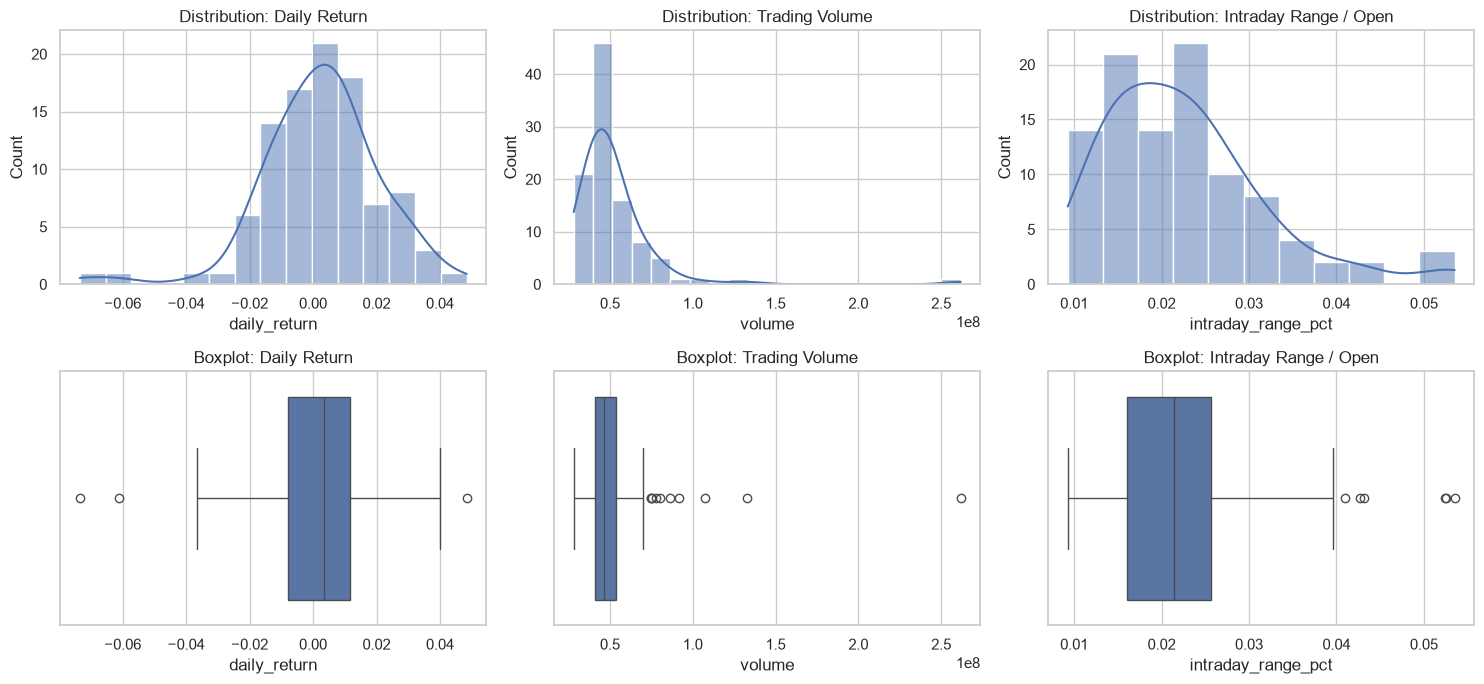

In [6]:
distribution_columns = ["daily_return", "volume", "intraday_range_pct"]
titles = ["Daily Return", "Trading Volume", "Intraday Range / Open"]
figure, axes = plt.subplots(2, 3, figsize=(15, 7))
for index, (column, title) in enumerate(zip(distribution_columns, titles)):
    sns.histplot(df[column].dropna(), kde=True, ax=axes[0, index])
    axes[0, index].set_title(f"Distribution: {title}")
    sns.boxplot(x=df[column], ax=axes[1, index])
    axes[1, index].set_title(f"Boxplot: {title}")
figure.tight_layout()
plt.show()

**Distribution read:** Daily returns are left-skewed and leptokurtic, so mean/standard-deviation summaries alone understate tail asymmetry. Intraday range is right-skewed, indicating a small number of unusually volatile sessions. Volume also contains high-end observations. Stage 09 features should therefore use lags and rolling statistics, while Stage 10b evaluation should include robust errors and time-ordered splits rather than assuming normality.

## 5. Bivariate Relationships

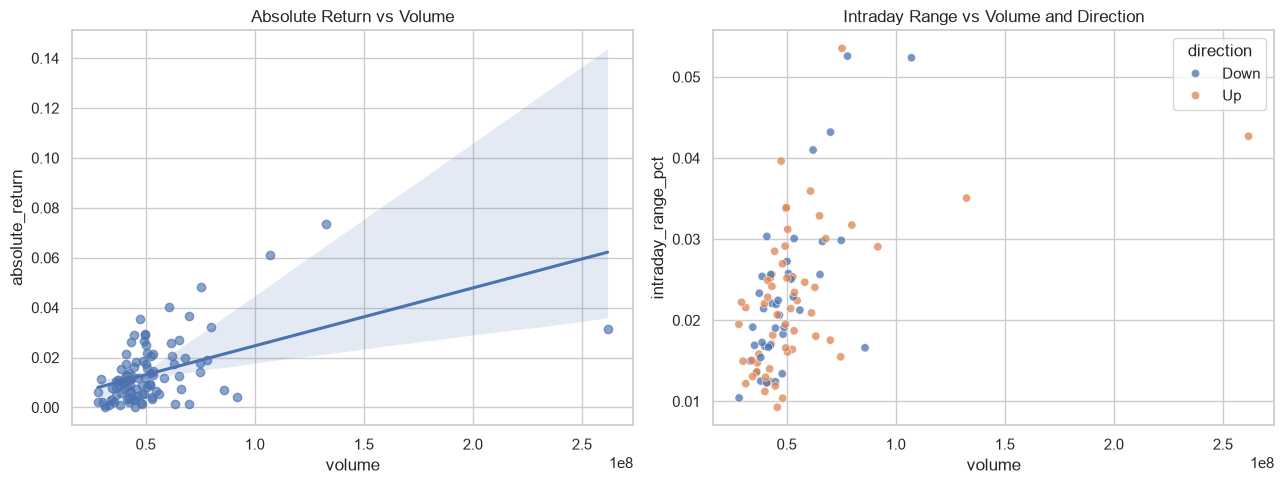

Correlation |return| vs volume: 0.496
Correlation intraday range vs volume: 0.525


In [7]:
figure, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.regplot(data=df, x="volume", y="absolute_return", scatter_kws={"alpha": 0.65}, ax=axes[0])
sns.scatterplot(data=df, x="volume", y="intraday_range_pct", hue="direction", alpha=0.75, ax=axes[1])
axes[0].set_title("Absolute Return vs Volume")
axes[1].set_title("Intraday Range vs Volume and Direction")
figure.tight_layout()
plt.show()
print("Correlation |return| vs volume:", round(df["absolute_return"].corr(df["volume"]), 3))
print("Correlation intraday range vs volume:", round(df["intraday_range_pct"].corr(df["volume"]), 3))

**Relationship read:** Volume has a meaningful positive association with absolute return and intraday range, while the direction colors overlap. Volume may help predict the magnitude of movement, but it does not by itself identify whether price will rise or fall.

## 6. Time-Series Structure

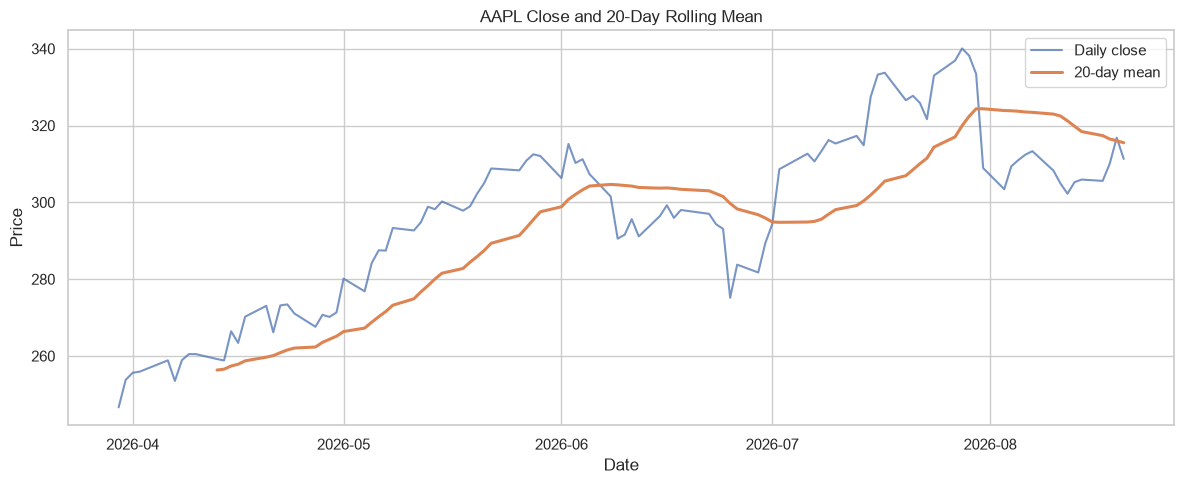

Missing weekdays (includes market holidays): 4


In [8]:
time_df = df.set_index("date").sort_index()
expected_days = pd.bdate_range(time_df.index.min(), time_df.index.max())
missing_business_days = expected_days.difference(time_df.index)
time_df["close_20d_mean"] = time_df["close"].rolling(20, min_periods=10).mean()
figure, axis = plt.subplots(figsize=(12, 5))
axis.plot(time_df.index, time_df["close"], label="Daily close", alpha=0.75)
axis.plot(time_df.index, time_df["close_20d_mean"], label="20-day mean", linewidth=2.2)
axis.set(title="AAPL Close and 20-Day Rolling Mean", xlabel="Date", ylabel="Price")
axis.legend()
figure.tight_layout()
plt.show()
print("Missing weekdays (includes market holidays):", len(missing_business_days))

**Time-series read:** The sample rises strongly from late March into May, shifts down during June, and recovers into July/August. These are level and volatility changes, not evidence of stable seasonality—the history is only about five months. Stage 09 should create lagged returns, rolling means, rolling volatility, range, and volume-change features without using future rows. Stage 10b should use walk-forward or time-ordered validation because a random split would leak regimes across train and test periods. Missing weekdays include exchange holidays, so reindexing and imputation must use a trading calendar rather than blindly filling every business day.

## 7. Stretch — Daily vs Monthly Granularity

,month_end_close,average_volume,return_volatility,trading_days
date,,,,
2026-03-31,253.79,4.452215e+07,NaN,2
2026-04-30,271.35,4.321612e+07,0.014830,21
2026-05-31,312.06,4.901822e+07,0.010970,20
2026-06-30,289.36,6.673584e+07,0.022011,21
2026-07-31,308.91,5.449587e+07,0.024486,22
2026-08-31,311.30,4.633236e+07,0.013332,14


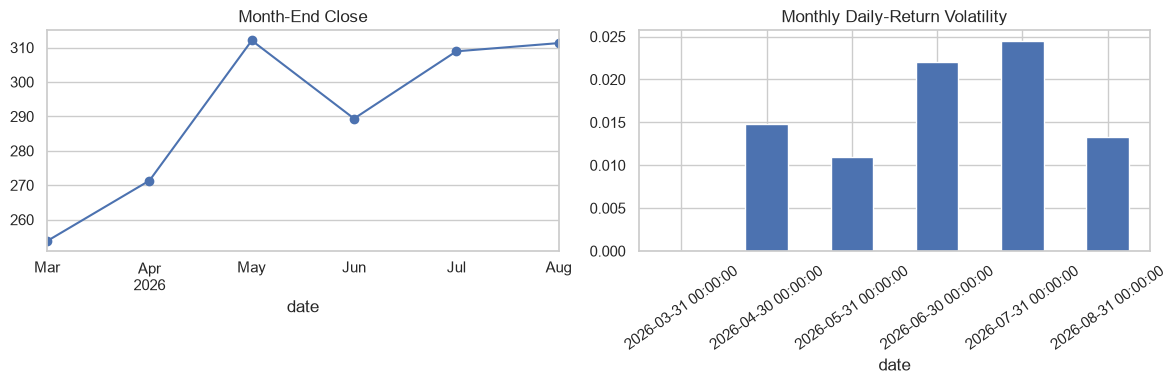

In [9]:
monthly = time_df.resample("ME").agg(
    month_end_close=("close", "last"),
    average_volume=("volume", "mean"),
    return_volatility=("daily_return", "std"),
    trading_days=("close", "size"),
)
display(monthly)
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
monthly["month_end_close"].plot(marker="o", ax=axes[0], title="Month-End Close")
monthly["return_volatility"].plot(kind="bar", ax=axes[1], title="Monthly Daily-Return Volatility")
axes[1].tick_params(axis="x", rotation=35)
figure.tight_layout()
plt.show()

**Granularity comparison:** Daily data reveals individual shocks and volatility clustering; monthly aggregation makes the May rise, June pullback, and July recovery clearer but leaves only six monthly observations. Monthly data is useful for communication, not for fitting a model at this sample size.

## 8. Stretch — Correlation Heatmap

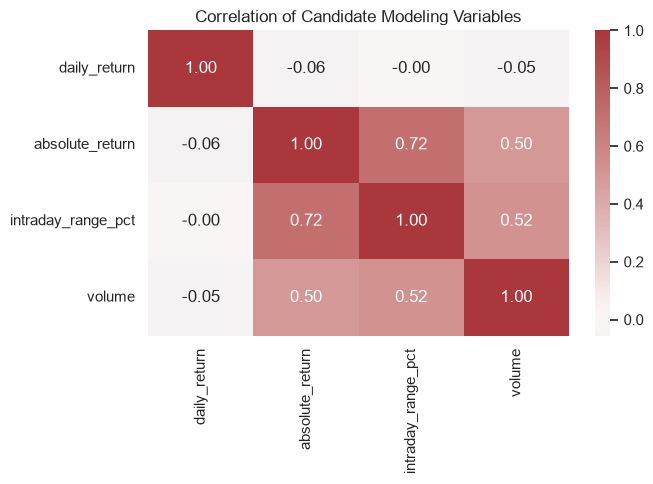

,daily_return,absolute_return,intraday_range_pct,volume
daily_return,1.000000,-0.056188,-0.004574,-0.046435
absolute_return,-0.056188,1.000000,0.716904,0.496265
intraday_range_pct,-0.004574,0.716904,1.000000,0.524887
volume,-0.046435,0.496265,0.524887,1.000000


In [10]:
modeling_columns = ["daily_return", "absolute_return", "intraday_range_pct", "volume"]
correlations = df[modeling_columns].corr()
figure, axis = plt.subplots(figsize=(7, 5))
sns.heatmap(correlations, annot=True, fmt=".2f", cmap="vlag", center=0, ax=axis)
axis.set_title("Correlation of Candidate Modeling Variables")
figure.tight_layout()
plt.show()
display(correlations)

The useful modeling signal is volume's association with movement magnitude and range, not a direct relationship with signed return. `absolute_return` and `intraday_range_pct` overlap conceptually, so feature selection or regularization should address redundancy.

## Top 3 Insights

1. **Returns are asymmetric and heavy-tailed.** Daily return is left-skewed with positive excess kurtosis; later modeling should not rely only on Gaussian assumptions or RMSE.
2. **Volume relates to movement magnitude, not direction.** High-volume sessions tend to have larger absolute returns and ranges, supporting lagged volume/range features but not a naive directional rule.
3. **The series contains regime-like level and volatility changes.** The rise into May, June pullback, and later recovery make temporal validation essential.

## Assumptions & Risks

- The 100-day Alpha Vantage sample is accurate, split-adjusted enough for this classroom analysis, and ordered by trading date; corporate actions should still be checked before longer-horizon modeling.
- The first return is missing by construction, not because acquisition failed. It should be dropped only after lagged features are built consistently.
- Five months cannot establish annual seasonality or stable relationships; correlations are descriptive and may be regime-specific.
- Derived categories simplify continuous behavior and should not replace numeric variables without validation.
- Same-day OHLCV relationships are not automatically usable for next-day forecasts; every predictor must be lagged to prevent leakage.

## Implications for Next Step

For Stage 09, engineer leakage-safe lagged returns, 5/20-day rolling return and volatility, lagged volume change, intraday range, and calendar fields; retain an outlier flag and consider robust scaling. For Stage 10b, compare a rolling-volatility baseline with simple regularized models using time-ordered or walk-forward splits. Report MAE alongside a tail-sensitive diagnostic, and test whether volume/range features improve held-out performance rather than trusting in-sample correlations.